# Diebold-Mariano Test — Pairwise Forecast Accuracy Comparison
## XGB-Hybrid Models: CNN, FNN, LSTM (Grid Search, Random Search, Optuna)

**Purpose:** The Diebold-Mariano (DM) test (Diebold & Mariano, 1995) formally tests whether
two forecasting models have **statistically equal predictive accuracy**.

**Loss differential:**  d_t = L(e1_t) − L(e2_t),  where L(e) = e² (MSE-based)

**Sign convention (critical for interpretation):**
- DM-stat > 0 → E[L(e1)] > E[L(e2)] → **Model 2 is more accurate** (lower loss)
- DM-stat < 0 → E[L(e1)] < E[L(e2)] → **Model 1 is more accurate** (lower loss)

**Reference:** Harvey, Leybourne & Newbold (1997) small-sample correction is applied.


## 1. Imports & Global Settings

In [1]:
# Standard libraries
import warnings
import random
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np   # Numerical operations
import pandas as pd  # Data manipulation and analysis

# Statistical testing
import itertools
from scipy import stats

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# ── Global random seed ────────────────────────────────────────────────────────
# The DM test is deterministic; the seed is set for reproducibility of any
# downstream stochastic operations.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Global random seed set to {RANDOM_SEED}")


Global random seed set to 42


## 2. Load Residual Series

### 2.1 XGB-CNN (Optuna) Residuals

In [2]:
# =============================================================================
# LOADING THE DATASET — XGB-CNN Optuna residuals (test-set only)
# Dataset source:
#   https://drive.google.com/file/d/1vq12zLxuXaDY_TD_LdQGOXs4uiYBBwRf/view?usp=sharing
# =============================================================================

file_id_cnn  = "1vq12zLxuXaDY_TD_LdQGOXs4uiYBBwRf"
url_cnn      = f"https://drive.google.com/uc?id={file_id_cnn}"

df_cnn = pd.read_csv(url_cnn)
df_cnn = df_cnn.set_index('Date')

# Extract the residual column as a 1-D array
Residual_Series_XGB_CNN_Optuna = df_cnn[["residuals_XGB_CNN_Optuna"]]

print("XGB-CNN Optuna residuals loaded.")
print(f"  Shape : {df_cnn.shape}")
print(f"  Period: {df_cnn.index[0]}  →  {df_cnn.index[-1]}")
display(df_cnn.head())


XGB-CNN Optuna residuals loaded.
  Shape : (803, 3)
  Period: 2021-10-20  →  2023-12-31


,WS10M,XGB_cnn_optuna,residuals_XGB_CNN_Optuna
Date,,,
2021-10-20,2.82,3.593197,-0.773197
2021-10-21,2.79,2.748255,0.041745
2021-10-22,2.72,2.689471,0.030529
2021-10-23,4.30,2.680005,1.619995
2021-10-24,3.74,3.882253,-0.142253


### 2.2 XGB-FNN (Optuna) Residuals

In [3]:
# =============================================================================
# LOADING THE DATASET — XGB-FNN Optuna residuals (test-set only)
# Dataset source:
#   https://drive.google.com/file/d/1_y7jvJpd9WJrY8UZ8sEWWlL5J9Q_Ekoq/view?usp=sharing
# =============================================================================

file_id_fnn  = "1_y7jvJpd9WJrY8UZ8sEWWlL5J9Q_Ekoq"
url_fnn      = f"https://drive.google.com/uc?id={file_id_fnn}"

df_fnn = pd.read_csv(url_fnn)
df_fnn = df_fnn.set_index('Date')

# Extract the residual column as a 1-D array
Residual_Series_XGB_FNN_Optuna = df_fnn[["residuals_XGB_FNN_Optuna"]]

print("XGB-FNN Optuna residuals loaded.")
print(f"  Shape : {df_fnn.shape}")
print(f"  Period: {df_fnn.index[0]}  →  {df_fnn.index[-1]}")
display(df_fnn.head())


XGB-FNN Optuna residuals loaded.
  Shape : (803, 3)
  Period: 10/20/2021  →  12/31/2023


,WS10M,XGB_fnn_optuna,residuals_XGB_FNN_Optuna
Date,,,
10/20/2021,2.82,3.821733,-1.001733
10/21/2021,2.79,2.869216,-0.079216
10/22/2021,2.72,2.671277,0.048723
10/23/2021,4.30,2.664988,1.635012
10/24/2021,3.74,3.706595,0.033405


### 2.3 XGB-LSTM (Grid Search) Residuals

In [4]:
# =============================================================================
# LOADING THE DATASET — XGB-LSTM Grid Search residuals (test-set only)
# Dataset source:
#   https://drive.google.com/file/d/1FHg4Wcj2oWRGjom8dzoKsIHfCjU8fw5Q/view?usp=sharing
# =============================================================================

file_id_lstm_gs  = "1FHg4Wcj2oWRGjom8dzoKsIHfCjU8fw5Q"
url_lstm_gs      = f"https://drive.google.com/uc?id={file_id_lstm_gs}"

df_lstm_gs = pd.read_csv(url_lstm_gs)
df_lstm_gs = df_lstm_gs.set_index('Date')

# Extract the residual column as a 1-D array
Residual_Series_XGB_LSTM_grid = df_lstm_gs[["residuals_XGB_LSTM_grid"]]

print("XGB-LSTM Grid Search residuals loaded.")
print(f"  Shape : {df_lstm_gs.shape}")
print(f"  Period: {df_lstm_gs.index[0]}  →  {df_lstm_gs.index[-1]}")
display(df_lstm_gs.head())


XGB-LSTM Grid Search residuals loaded.
  Shape : (803, 3)
  Period: 2021-10-20  →  2023-12-31


,WS10M,XGB_LSTM_grid,residuals_XGB_LSTM_grid
Date,,,
2021-10-20,2.82,3.773680,-0.953679
2021-10-21,2.79,2.868019,-0.078019
2021-10-22,2.72,2.673751,0.046249
2021-10-23,4.30,2.669313,1.630687
2021-10-24,3.74,3.733953,0.006047


### 2.4 XGB-LSTM (Randomized Search) Residuals

In [5]:
# =============================================================================
# LOADING THE DATASET — XGB-LSTM Randomized Search residuals (test-set only)
# Dataset source:
#   https://drive.google.com/file/d/1INo2vXU58MUS257e2CEDLR7oc3EfXry9/view?usp=sharing
# =============================================================================

file_id_lstm_rs  = "1INo2vXU58MUS257e2CEDLR7oc3EfXry9"
url_lstm_rs      = f"https://drive.google.com/uc?id={file_id_lstm_rs}"

df_lstm_rs = pd.read_csv(url_lstm_rs, parse_dates=['Date'])
df_lstm_rs = df_lstm_rs.set_index('Date')

# Extract the residual column as a 1-D array
Residual_Series_XGB_LSTM_random = df_lstm_rs[["residuals_XGB_LSTM_random"]]

print("XGB-LSTM Randomized Search residuals loaded.")
print(f"  Shape : {df_lstm_rs.shape}")
print(f"  Period: {df_lstm_rs.index[0]}  →  {df_lstm_rs.index[-1]}")
display(df_lstm_rs.head())


XGB-LSTM Randomized Search residuals loaded.
  Shape : (803, 3)
  Period: 2021-10-20 00:00:00  →  2023-12-31 00:00:00


,WS10M,XGB_LSTM_random,residuals_XGB_LSTM_random
Date,,,
2021-10-20,2.82,3.776921,-0.956921
2021-10-21,2.79,2.855307,-0.065307
2021-10-22,2.72,2.673000,0.047000
2021-10-23,4.30,2.654569,1.645431
2021-10-24,3.74,3.729120,0.010880


### 2.5 XGB-LSTM (Optuna) Residuals

In [6]:
# =============================================================================
# LOADING THE DATASET — XGB-LSTM Optuna residuals (test-set only)
# Dataset source:
#   https://drive.google.com/file/d/1V8TkxVz2giodwJxjxS3SGIHRyVXz6e7g/view?usp=sharing
# =============================================================================

file_id_lstm_opt = "1V8TkxVz2giodwJxjxS3SGIHRyVXz6e7g"
url_lstm_opt     = f"https://drive.google.com/uc?id={file_id_lstm_opt}"

df_lstm_opt = pd.read_csv(url_lstm_opt, parse_dates=['Date'])
df_lstm_opt = df_lstm_opt.set_index('Date')

# Extract the residual column as a 1-D array
Residual_Series_XGB_LSTM_opt = df_lstm_opt[["residuals_XGB_LSTM_optuna"]]

print("XGB-LSTM Optuna residuals loaded.")
print(f"  Shape : {df_lstm_opt.shape}")
print(f"  Period: {df_lstm_opt.index[0]}  →  {df_lstm_opt.index[-1]}")
display(df_lstm_opt.head())


XGB-LSTM Optuna residuals loaded.
  Shape : (803, 3)
  Period: 2021-10-20 00:00:00  →  2023-12-31 00:00:00


,WS10M,XGB_LSTM_optuna,residuals_XGB_LSTM_optuna
Date,,,
2021-10-20,2.82,3.778142,-0.958142
2021-10-21,2.79,2.868721,-0.078721
2021-10-22,2.72,2.669573,0.050427
2021-10-23,4.30,2.616495,1.683505
2021-10-24,3.74,3.711182,0.028818


## 3. Residual Series Alignment Check

In [7]:
# =============================================================================
# ALIGNMENT CHECK
# The DM test requires that all residual series cover the SAME time period
# and have the SAME number of observations.
# If lengths differ (e.g., different test-set splits), the pairwise numpy
# operations inside diebold_mariano() will raise a ValueError.
# =============================================================================

series_info = {
    "XGB_CNN_Optuna":    Residual_Series_XGB_CNN_Optuna,
    "XGB_FNN_Optuna":    Residual_Series_XGB_FNN_Optuna,
    "XGB_LSTM_grid":     Residual_Series_XGB_LSTM_grid,
    "XGB_LSTM_random":   Residual_Series_XGB_LSTM_random,
    "XGB_LSTM_opt":      Residual_Series_XGB_LSTM_opt,
}

lengths = {name: len(s) for name, s in series_info.items()}
print("Series lengths:")
for name, n in lengths.items():
    print(f"  {name:25s}: {n}")

unique_lengths = set(lengths.values())
if len(unique_lengths) == 1:
    print("\n✓ All series have the same length — alignment OK.")
else:
    print("\n⚠ WARNING: Series have DIFFERENT lengths!")
    print("  Truncating all series to the shortest common length for valid comparison.")
    min_len = min(unique_lengths)
    for name in series_info:
        series_info[name] = series_info[name].iloc[-min_len:]   # keep most-recent observations
    print(f"  All series truncated to last {min_len} observations.")

# Rebuild flattened arrays after alignment
Residual_Series_XGB_CNN_Optuna  = series_info["XGB_CNN_Optuna"]
Residual_Series_XGB_FNN_Optuna  = series_info["XGB_FNN_Optuna"]
Residual_Series_XGB_LSTM_grid   = series_info["XGB_LSTM_grid"]
Residual_Series_XGB_LSTM_random = series_info["XGB_LSTM_random"]
Residual_Series_XGB_LSTM_opt    = series_info["XGB_LSTM_opt"]


Series lengths:
  XGB_CNN_Optuna           : 803
  XGB_FNN_Optuna           : 803
  XGB_LSTM_grid            : 803
  XGB_LSTM_random          : 803
  XGB_LSTM_opt             : 803

✓ All series have the same length — alignment OK.


## 4. Diebold-Mariano Test Implementation

The DM test (Diebold & Mariano, 1995) tests H₀: E[d_t] = 0, where
d_t = L(e1_t) − L(e2_t) is the loss differential.

The Harvey, Leybourne & Newbold (1997) correction is applied to improve
small-sample performance by using a t-distribution with n−1 degrees of freedom.

**Sign convention:**
- DM-stat > 0  →  L(e1) > L(e2)  →  **Model 2 (e2) is more accurate**
- DM-stat < 0  →  L(e1) < L(e2)  →  **Model 1 (e1) is more accurate**


In [8]:
def diebold_mariano(e1, e2, h=1, power=2):
    """
    Diebold-Mariano test for equal predictive accuracy.

    Parameters
    ----------
    e1, e2 : array-like
        Forecast errors (actual − predicted) for models 1 and 2.
        Must have the same length and cover the same time period.
    h : int
        Forecast horizon (default 1 for one-step-ahead).
    power : int
        Loss function power: 2 = MSE-based (default), 1 = MAE-based.

    Returns
    -------
    dm_stat : float
        DM test statistic.
        Positive → Model 1 has larger loss → Model 2 is more accurate.
        Negative → Model 2 has larger loss → Model 1 is more accurate.
    p_value : float
        Two-sided p-value based on the Harvey et al. (1997) t-distribution.

    Notes
    -----
    The Harvey, Leybourne & Newbold (1997) small-sample correction multiplies
    the variance by (n + 1 − 2h + h(h−1)/n) / n and uses a t(n−1) distribution
    instead of N(0,1). This correction is recommended for finite samples.

    Loss differential: d_t = |e1_t|^power − |e2_t|^power
    H0: E[d_t] = 0  (equal predictive accuracy)
    H1: E[d_t] ≠ 0  (one model is significantly more accurate)
    """
    e1 = np.asarray(e1).flatten()
    e2 = np.asarray(e2).flatten()

    if len(e1) != len(e2):
        raise ValueError(
            f"Residual series must have the same length. "
            f"Got {len(e1)} and {len(e2)}."
        )

    n = len(e1)

    # Loss differential
    d     = np.abs(e1) ** power - np.abs(e2) ** power
    d_bar = np.mean(d)

    # Newey-West autocovariance estimator (truncated at h-1 lags)
    def autocov(k):
        return np.sum((d[k:] - d_bar) * (d[:n - k] - d_bar)) / n

    gamma_0 = autocov(0)
    gamma   = sum(2 * autocov(lag) for lag in range(1, h))  # empty for h=1
    var_d   = gamma_0 + gamma

    # Guard against degenerate / zero-variance case
    if var_d <= 0:
        return np.nan, np.nan

    # ── Harvey, Leybourne & Newbold (1997) small-sample correction ───────────
    # Corrected variance: multiply by (n + 1 - 2h + h*(h-1)/n) / n
    hln_correction = (n + 1 - 2 * h + h * (h - 1) / n) / n
    dm_stat = d_bar / np.sqrt(var_d / n)

    # HLN-corrected statistic uses t(n-1) distribution
    dm_stat_hln = dm_stat * np.sqrt(hln_correction)
    p_value = 2 * (1 - stats.t.cdf(np.abs(dm_stat_hln), df=n - 1))

    return dm_stat_hln, p_value


def dm_decision(dm_stat, p_value, model1_name, model2_name, alpha=0.05):
    """
    Interpret DM test result using correct sign convention.

    SIGN CONVENTION:
        d_t = L(e1_t) - L(e2_t)
        dm_stat > 0  →  Model 1 has LARGER loss  →  Model 2 is more accurate
        dm_stat < 0  →  Model 1 has SMALLER loss →  Model 1 is more accurate
    """
    if np.isnan(dm_stat) or np.isnan(p_value):
        return "Indeterminate (degenerate variance)"
    if p_value >= alpha:
        return "No significant difference"
    # dm_stat > 0: e1 loss > e2 loss → model 2 wins
    # dm_stat < 0: e1 loss < e2 loss → model 1 wins
    if dm_stat > 0:
        return f"{model2_name} is significantly more accurate"
    else:
        return f"{model1_name} is significantly more accurate"


## 5. Pairwise DM Test — Printed Results

In [9]:
# =============================================================================
# Pairwise DM test — printed summary for all model combinations
# =============================================================================

# Residuals dictionary (flattened 1-D arrays)
residuals_dict = {
    "XGB_LSTM_opt":    Residual_Series_XGB_LSTM_opt.values.flatten(),
    "XGB_LSTM_random": Residual_Series_XGB_LSTM_random.values.flatten(),
    "XGB_LSTM_grid":   Residual_Series_XGB_LSTM_grid.values.flatten(),
    "XGB_FNN_Optuna":  Residual_Series_XGB_FNN_Optuna.values.flatten(),
    "XGB_CNN_Optuna":  Residual_Series_XGB_CNN_Optuna.values.flatten()
}

pairs = list(itertools.combinations(residuals_dict.keys(), 2))

print("=" * 70)
print("Diebold-Mariano Test — Pairwise Comparisons (h=1, MSE-based loss)")
print("Harvey, Leybourne & Newbold (1997) correction applied")
print("=" * 70)

for model1, model2 in pairs:
    e1 = residuals_dict[model1]
    e2 = residuals_dict[model2]

    dm_stat, p_value = diebold_mariano(e1, e2, h=1, power=2)
    decision         = dm_decision(dm_stat, p_value, model1, model2)

    sig = "**" if (not np.isnan(p_value) and p_value < 0.05) else "  "
    print(f"{sig} {model1:20s} vs {model2:20s} | "
          f"DM={dm_stat:+.4f}  p={p_value:.4f} | {decision}")

print("\n** = significant at α = 0.05")
print("\nSign convention: DM > 0 → Model 1 has larger loss → Model 2 is more accurate")
print("                 DM < 0 → Model 1 has smaller loss → Model 1 is more accurate")


Diebold-Mariano Test — Pairwise Comparisons (h=1, MSE-based loss)
Harvey, Leybourne & Newbold (1997) correction applied
   XGB_LSTM_opt         vs XGB_LSTM_random      | DM=+0.5952  p=0.5519 | No significant difference
   XGB_LSTM_opt         vs XGB_LSTM_grid        | DM=-0.1850  p=0.8533 | No significant difference
   XGB_LSTM_opt         vs XGB_FNN_Optuna       | DM=-0.4720  p=0.6370 | No significant difference
** XGB_LSTM_opt         vs XGB_CNN_Optuna       | DM=-2.2585  p=0.0242 | XGB_LSTM_opt is significantly more accurate
   XGB_LSTM_random      vs XGB_LSTM_grid        | DM=-1.3331  p=0.1829 | No significant difference
   XGB_LSTM_random      vs XGB_FNN_Optuna       | DM=-0.6952  p=0.4871 | No significant difference
** XGB_LSTM_random      vs XGB_CNN_Optuna       | DM=-2.4380  p=0.0150 | XGB_LSTM_random is significantly more accurate
   XGB_LSTM_grid        vs XGB_FNN_Optuna       | DM=-0.4197  p=0.6748 | No significant difference
** XGB_LSTM_grid        vs XGB_CNN_Optuna       |

## 6. DM Test — Matrix Results

In [10]:
# =============================================================================
# Pairwise DM test — upper-triangular matrix form
# Rows = Model 1 (e1), Columns = Model 2 (e2)
# DM-stat > 0 in cell (i,j) means column model j is MORE accurate than row i
# =============================================================================

models = list(residuals_dict.keys())

dm_stat_matrix = pd.DataFrame(np.nan,  index=models, columns=models)
p_value_matrix = pd.DataFrame(np.nan,  index=models, columns=models)
decision_matrix = pd.DataFrame("",     index=models, columns=models)

# ── Compute upper triangle ────────────────────────────────────────────────────
for i, m1 in enumerate(models):
    for j, m2 in enumerate(models):
        if i == j:
            # Self-comparison: identical series → no test
            dm_stat_matrix.loc[m1, m2]  = 0.0
            p_value_matrix.loc[m1, m2]  = np.nan   # undefined for self-comparison
            decision_matrix.loc[m1, m2] = "—"
        elif i < j:
            # Upper triangle: compute DM test
            e1 = residuals_dict[m1]
            e2 = residuals_dict[m2]
            dm_stat, p_value = diebold_mariano(e1, e2, h=1, power=2)

            dm_stat_matrix.loc[m1, m2]  = dm_stat
            p_value_matrix.loc[m1, m2]  = p_value
            decision_matrix.loc[m1, m2] = dm_decision(
                dm_stat, p_value, m1, m2
            )
        else:
            # Lower triangle: symmetric mirror
            dm_stat_matrix.loc[m1, m2]  = -dm_stat_matrix.loc[m2, m1]   # sign-flipped
            p_value_matrix.loc[m1, m2]  =  p_value_matrix.loc[m2, m1]   # same p-value
            decision_matrix.loc[m1, m2] =  decision_matrix.loc[m2, m1]  # same decision

# ── Display matrices ──────────────────────────────────────────────────────────
print("=== DM Statistic Matrix (upper triangle) ===")
print("Positive value in (row i, col j) → col j model has LOWER loss → is MORE accurate")
display(dm_stat_matrix.round(4))

print("\n=== DM P-Value Matrix ===")
display(p_value_matrix.round(4))

print("\n=== DM Decision Matrix ===")
display(decision_matrix)


=== DM Statistic Matrix (upper triangle) ===
Positive value in (row i, col j) → col j model has LOWER loss → is MORE accurate


,XGB_LSTM_opt,XGB_LSTM_random,XGB_LSTM_grid,XGB_FNN_Optuna,XGB_CNN_Optuna
XGB_LSTM_opt,0.0000,0.5952,-0.1850,-0.4720,-2.2585
XGB_LSTM_random,-0.5952,0.0000,-1.3331,-0.6952,-2.4380
XGB_LSTM_grid,0.1850,1.3331,0.0000,-0.4197,-2.2645
XGB_FNN_Optuna,0.4720,0.6952,0.4197,0.0000,-1.4797
XGB_CNN_Optuna,2.2585,2.4380,2.2645,1.4797,0.0000



=== DM P-Value Matrix ===


,XGB_LSTM_opt,XGB_LSTM_random,XGB_LSTM_grid,XGB_FNN_Optuna,XGB_CNN_Optuna
XGB_LSTM_opt,NaN,0.5519,0.8533,0.6370,0.0242
XGB_LSTM_random,0.5519,NaN,0.1829,0.4871,0.0150
XGB_LSTM_grid,0.8533,0.1829,NaN,0.6748,0.0238
XGB_FNN_Optuna,0.6370,0.4871,0.6748,NaN,0.1393
XGB_CNN_Optuna,0.0242,0.0150,0.0238,0.1393,NaN



=== DM Decision Matrix ===


,XGB_LSTM_opt,XGB_LSTM_random,XGB_LSTM_grid,XGB_FNN_Optuna,XGB_CNN_Optuna
XGB_LSTM_opt,—,No significant difference,No significant difference,No significant difference,XGB_LSTM_opt is significantly more accurate
XGB_LSTM_random,No significant difference,—,No significant difference,No significant difference,XGB_LSTM_random is significantly more accurate
XGB_LSTM_grid,No significant difference,No significant difference,—,No significant difference,XGB_LSTM_grid is significantly more accurate
XGB_FNN_Optuna,No significant difference,No significant difference,No significant difference,—,No significant difference
XGB_CNN_Optuna,XGB_LSTM_opt is significantly more accurate,XGB_LSTM_random is significantly more accurate,XGB_LSTM_grid is significantly more accurate,No significant difference,—


## 7. DM Test — Heatmap Visualisations

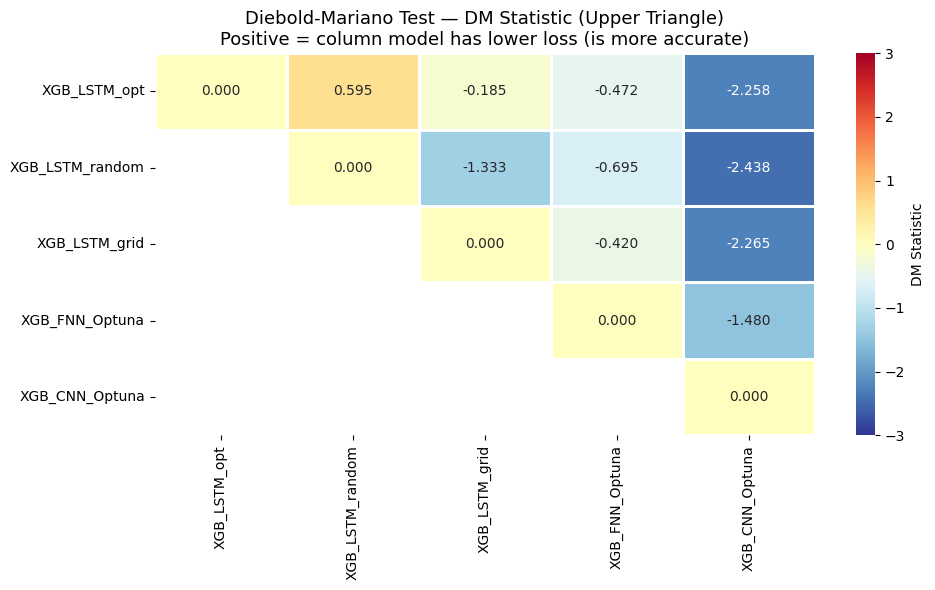

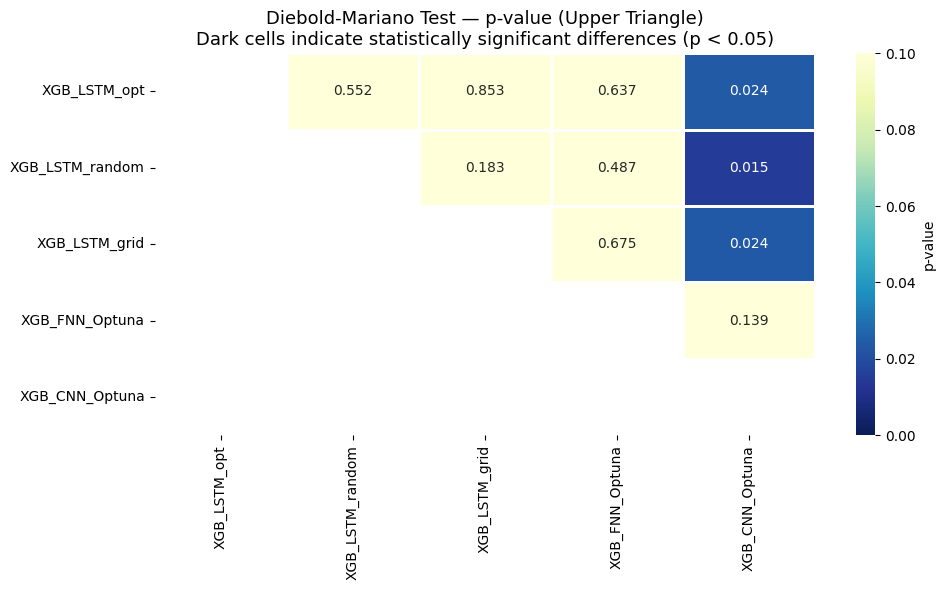

=== DM Test Decision Matrix (Upper Triangular) ===


,XGB_LSTM_opt,XGB_LSTM_random,XGB_LSTM_grid,XGB_FNN_Optuna,XGB_CNN_Optuna
XGB_LSTM_opt,—,No significant difference,No significant difference,No significant difference,XGB_LSTM_opt is significantly more accurate
XGB_LSTM_random,No significant difference,—,No significant difference,No significant difference,XGB_LSTM_random is significantly more accurate
XGB_LSTM_grid,No significant difference,No significant difference,—,No significant difference,XGB_LSTM_grid is significantly more accurate
XGB_FNN_Optuna,No significant difference,No significant difference,No significant difference,—,No significant difference
XGB_CNN_Optuna,XGB_LSTM_opt is significantly more accurate,XGB_LSTM_random is significantly more accurate,XGB_LSTM_grid is significantly more accurate,No significant difference,—


In [11]:
# =============================================================================
# Heatmap visualisations: DM statistic and p-value (upper triangle only)
# =============================================================================

# Upper-triangle mask (True = hide the cell)
mask = np.tril(np.ones((len(models), len(models)), dtype=bool), k=-1)

# ── Heatmap 1: DM Statistic ───────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
sns.heatmap(
    dm_stat_matrix.astype(float),
    annot=True, fmt=".3f",
    cmap="RdYlBu_r",
    mask=mask,                         # show only upper triangle + diagonal
    cbar_kws={'label': 'DM Statistic'},
    linewidths=0.8, linecolor='white',
    vmin=-3, vmax=3                    # symmetric colour scale
)
plt.title(
    "Diebold-Mariano Test — DM Statistic (Upper Triangle)\n"
    "Positive = column model has lower loss (is more accurate)",
    fontsize=13
)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ── Heatmap 2: p-values ───────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
sns.heatmap(
    p_value_matrix.astype(float),
    annot=True, fmt=".3f",
    cmap="YlGnBu_r",
    mask=mask,
    cbar_kws={'label': 'p-value'},
    linewidths=0.8, linecolor='white',
    vmin=0, vmax=0.1
)
plt.title(
    "Diebold-Mariano Test — p-value (Upper Triangle)\n"
    "Dark cells indicate statistically significant differences (p < 0.05)",
    fontsize=13
)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ── Final display: decision matrix ───────────────────────────────────────────
print("=== DM Test Decision Matrix (Upper Triangular) ===")
display(decision_matrix)
